In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv("cpi_data.csv")

print(df.head())
print(df.info())

        Sector  Year     Month  Cereals and products  Meat and fish    Egg  \
0        Rural  2013   January                 107.5          106.3  108.1   
1        Urban  2013   January                 110.5          109.1  113.0   
2  Rural+Urban  2013   January                 108.4          107.3  110.0   
3        Rural  2013  February                 109.2          108.7  110.2   
4        Urban  2013  February                 112.9          112.9  116.9   

   Milk and products  Oils and fats  Fruits  Vegetables  ...  Housing  \
0              104.9          106.1   103.9       101.9  ...      NaN   
1              103.6          103.4   102.3       102.9  ...    100.3   
2              104.4          105.1   103.2       102.2  ...    100.3   
3              105.4          106.7   104.0       102.4  ...      NaN   
4              104.0          103.5   103.1       104.9  ...    100.4   

   Fuel and light  Household goods and services  Health  \
0           105.5                

In [3]:
df = df.drop(columns=["Sector","Month"], errors="ignore")

df = df.apply(pd.to_numeric, errors="coerce")

df = df.dropna()

In [4]:
X = df.drop(columns=["General index"])
y = df["General index"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor()
}

In [7]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results.append((name, mae, r2))
    
    print("\nModel:", name)
    print("MAE:", mae)
    print("R2:", r2)


Model: Linear Regression
MAE: 0.11302433275935013
R2: 0.9999525993699191

Model: Decision Tree
MAE: 0.9489795918367353
R2: 0.997232353754096

Model: Random Forest
MAE: 0.4655306122448859
R2: 0.9992586039327086

Model: Gradient Boosting
MAE: 0.376534248005728
R2: 0.9994908930332204


               Model       MAE        R2
0  Linear Regression  0.113024  0.999953
1      Decision Tree  0.948980  0.997232
2      Random Forest  0.465531  0.999259
3  Gradient Boosting  0.376534  0.999491


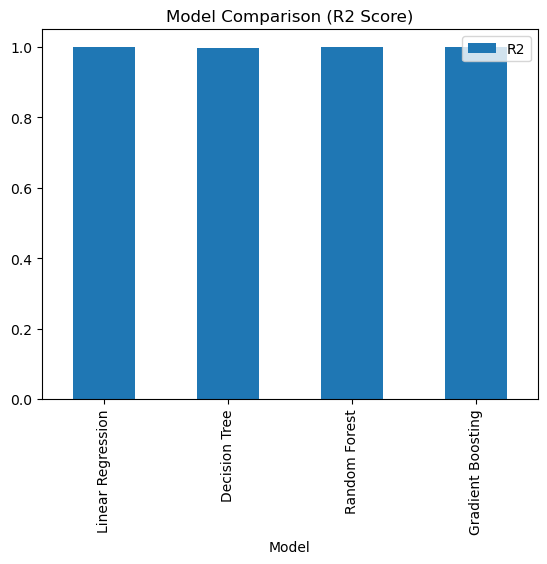

In [8]:
results_df = pd.DataFrame(results, columns=["Model","MAE","R2"])

print(results_df)

results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    title="Model Comparison (R2 Score)"
)

plt.show()